## 3 - Baseline ML Models for RUL Prediction
**Thesis:** Bayesian ML for Real-Time RUL Prediction of Industrial Rotating Equipment

**Goal:**
- Establish non-Bayesian **baselines** that the Bayesian tier (NB4) must beat
- Progressively increase complexity: **Linear Regression → XGBoost → MLP → LSTM**
- Plus a **mean-predictor floor** (sanity / feasibility check)
- Evaluate every model with the SAME RUL metrics on the held-out run **test3**

In [1]:
# Standard library
import os, time, pickle, warnings

# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import PredictionErrorDisplay
from sklearn.preprocessing import StandardScaler

# Scikit-learn: models
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
np.random.seed(SEED)

#### 1. Data Loading

In [2]:
# Load the ML-ready artifacts exported by Notebook 2
PREP_DIR = './preprocessing_output'     
OUT_DIR  = './baseline_output'
os.makedirs(OUT_DIR, exist_ok=True)

flat = np.load(os.path.join(PREP_DIR, 'flat.npz'))
seq  = np.load(os.path.join(PREP_DIR, 'sequences.npz'))
with open(os.path.join(PREP_DIR, 'metadata.pkl'), 'rb') as f:
    META = pickle.load(f)

# Flat (tabular) arrays — for Linear Regression / XGBoost / MLP
Xf_train, yf_train = flat['X_train'], flat['y_train']
Xf_val,   yf_val   = flat['X_val'],   flat['y_val']
Xf_test,  yf_test  = flat['X_test'],  flat['y_test']

# Sequence arrays — for LSTM
Xs_train, ys_train = seq['X_train'], seq['y_train']
Xs_val,   ys_val   = seq['X_val'],   seq['y_val']
Xs_test,  ys_test  = seq['X_test'],  seq['y_test']

# LDS sample weights (imbalance handling, TRAIN only) (LDS-Label Distribution Smoothing)
sw_flat = flat['sample_weight_train'] if 'sample_weight_train' in flat.files else None
sw_seq  = seq['sample_weight_train']  if 'sample_weight_train'  in seq.files  else None

FEATURE_COLS = META['feature_cols']
MAX_RUL_TEST = float(META['max_rul_per_test']['test3'])   # minutes, for de-normalisation
SNAPSHOT_MIN = 10.0   # IMS recording interval — used to express RUL in 'cycles' for the CMAPSS score

print(f'Flat   : train {Xf_train.shape} | val {Xf_val.shape} | test {Xf_test.shape}')
print(f'Seq    : train {Xs_train.shape} | val {Xs_val.shape} | test {Xs_test.shape}')
print(f'Weights: flat={None if sw_flat is None else sw_flat.shape} | seq={None if sw_seq is None else sw_seq.shape}')
print(f'n_features = {len(FEATURE_COLS)} | MAX_RUL(test3) = {MAX_RUL_TEST:.0f} min')

Flat   : train (788, 15) | val (196, 15) | test (6324, 15)
Seq    : train (730, 30, 15) | val (138, 30, 15) | test (6295, 30, 15)
Weights: flat=(788,) | seq=(730,)
n_features = 15 | MAX_RUL(test3) = 1520 min


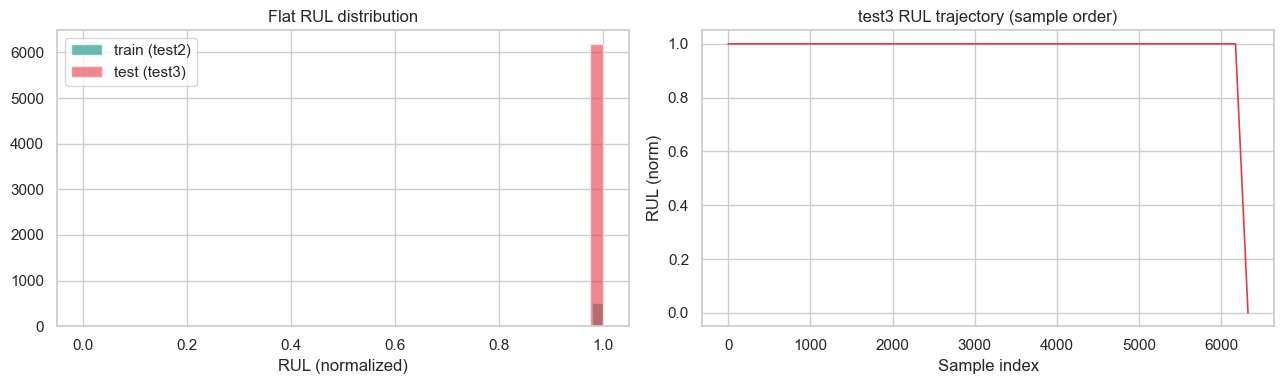

In [3]:
# Quick look at the RUL label distribution per split (sanity)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(yf_train, bins=40, alpha=0.7, label='train (test2)', color='#2a9d8f')
ax[0].hist(yf_test,  bins=40, alpha=0.6, label='test (test3)',  color='#e63946')
ax[0].set_title('Flat RUL distribution'); ax[0].set_xlabel('RUL (normalized)'); ax[0].legend()
ax[1].plot(yf_test, color='#e63946', lw=1.2)
ax[1].set_title('test3 RUL trajectory (sample order)'); ax[1].set_xlabel('Sample index'); ax[1].set_ylabel('RUL (norm)')
plt.tight_layout(); plt.show()

#### 2. Evaluation Utilities (RUL metrics)
One metric set for all models: RMSE / MAE in normalised **and** minute scales, plus a
CMAPSS-style **asymmetric score** (late predictions penalised more). We also record
train and inference time — relevant to the "real-time" goal.

In [4]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true, float) - np.asarray(y_pred, float)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))

# CMAPSS-style asymmetric RUL score in minutes (lower = better)
# late predictions (pred > true) cost more than early ones
def asymmetric_score(y_true_min, y_pred_min, a_early=13.0, a_late=10.0):
    d = np.asarray(y_pred_min, float) - np.asarray(y_true_min, float)
    return float(np.sum(np.where(d < 0, np.exp(-d / a_early) - 1.0, np.exp(d / a_late) - 1.0)))

RESULTS = []   # collector — one dict per model

# computes the metric set, prints it, stores a result dict (like res_lr etc.)
def eval_rul(name, y_true, y_pred, train_time=np.nan, pred_time=np.nan,
             model=None, max_rul=MAX_RUL_TEST, note=''):
    y_true = np.asarray(y_true, float)
    y_pred = np.clip(np.asarray(y_pred, float), 0.0, 1.0)
    yt_min, yp_min = y_true * max_rul, y_pred * max_rul
    # asymmetric score on 'cycle' scale (minutes / 10-min snapshot) so the CMAPSS
    # constants (10/13) stay in their intended range and the score is readable
    yt_cyc, yp_cyc = yt_min / SNAPSHOT_MIN, yp_min / SNAPSHOT_MIN
    r = {'model_name': name, 'model': model,
         'rmse_norm': rmse(y_true, y_pred), 'mae_norm': mae(y_true, y_pred),
         'rmse_min':  rmse(yt_min, yp_min), 'mae_min':  mae(yt_min, yp_min),
         'score':     asymmetric_score(yt_cyc, yp_cyc),
         'train_time': train_time, 'pred_time': pred_time,
         'y_true': y_true, 'y_pred': y_pred, 'note': note}
    RESULTS.append(r)
    print(f'{name}')
    print(f'  RMSE (norm) : {r["rmse_norm"]:.4f}   |  MAE (norm) : {r["mae_norm"]:.4f}')
    print(f'  RMSE (min)  : {r["rmse_min"]:.1f}    |  MAE (min)  : {r["mae_min"]:.1f}')
    print(f'  Asym score  : {r["score"]:.1f}')
    print(f'  Train time  : {train_time:.3f}s  |  Pred time : {pred_time:.4f}s')
    return r

In [5]:
# Sanity floor: mean predictor — always predicts the mean train RUL
# every real model must beat this, otherwise the pipeline is suspect, not the model
y_mean = float(yf_train.mean())
eval_rul('Mean predictor (floor)', yf_test, np.full_like(yf_test, y_mean),
         train_time=0.0, pred_time=0.0, note='sanity floor — not a real model')

Mean predictor (floor)
  RMSE (norm) : 0.1756   |  MAE (norm) : 0.1682
  RMSE (min)  : 266.9    |  MAE (min)  : 255.7
  Asym score  : 3537111.5
  Train time  : 0.000s  |  Pred time : 0.0000s


{'model_name': 'Mean predictor (floor)',
 'model': None,
 'rmse_norm': 0.1755907176755249,
 'mae_norm': 0.168241300537881,
 'rmse_min': 266.8978908667979,
 'mae_min': 255.7267768175792,
 'score': 3537111.5156017756,
 'train_time': 0.0,
 'pred_time': 0.0,
 'y_true': array([1.        , 1.        , 1.        , ..., 0.01315789, 0.00657895,
        0.        ]),
 'y_pred': array([0.83661744, 0.83661744, 0.83661744, ..., 0.83661744, 0.83661744,
        0.83661744]),
 'note': 'sanity floor — not a real model'}

#### 3. Baseline Models

In [6]:
print('min :', Xf_train.min(axis=0))
print('max :', Xf_train.max(axis=0))
print('mean:', Xf_train.mean(axis=0))
print('std :', Xf_train.std(axis=0))

min : [ -4.1905353   -1.54492355  -1.85200416 -13.07724874  -2.15952017
  -4.40874573  -3.91638485  -1.65141347  -2.410795    -5.67660449
  -2.05419669  -1.94192649  -2.63690769  -5.38910568  -3.37672047]
max : [142.19334983  29.23738682  31.83190321   3.41976425   3.71013552
 123.49322429 208.58539861   3.77650001   2.35247047   4.26953504
   1.64219912   2.73910131   3.19770614   2.50182095  21.86868879]
mean: [30.5961357   6.38228105  6.33200499 -1.9473235  -0.58025    26.61678521
 41.92798179 -0.12509117  0.0963889  -1.01732048 -0.27193465 -0.40830654
  0.89439829 -1.39033938  3.71081075]
std : [44.37869523 10.04786552 10.58594185  2.9293163   0.80844259 38.53119197
 64.62576487  0.96933262  0.94178095  1.71361626  0.80026907  0.87195661
  1.03349143  1.90156733  5.15391652]


#### 3.1 Linear Regression
The simplest learned baseline (no hyperparameters). With LDS sample weights so the
near-failure region is up-weighted, consistent with the other models.

In [7]:
# Model Initialization + Training
lr_model = LinearRegression(n_jobs=-1)

t0 = time.time()
lr_model.fit(Xf_train, yf_train, sample_weight=sw_flat)   # sw_flat may be None
lr_train_time = time.time() - t0
print(f'Linear Regression trained in {lr_train_time:.3f}s  (weighted={sw_flat is not None})')

Linear Regression trained in 0.010s  (weighted=True)


In [8]:
# Predict + Evaluate
t0 = time.time()
lr_pred = lr_model.predict(Xf_test)
lr_pred_time = time.time() - t0

res_lr = eval_rul('Linear Regression', yf_test, lr_pred,
                  lr_train_time, lr_pred_time, model=lr_model)

Linear Regression
  RMSE (norm) : 0.1727   |  MAE (norm) : 0.0864
  RMSE (min)  : 262.5    |  MAE (min)  : 131.3
  Asym score  : 2898165.9
  Train time  : 0.010s  |  Pred time : 0.0010s


Text(0.5, 1.0, 'Linear Regression — Predicted vs Actual')

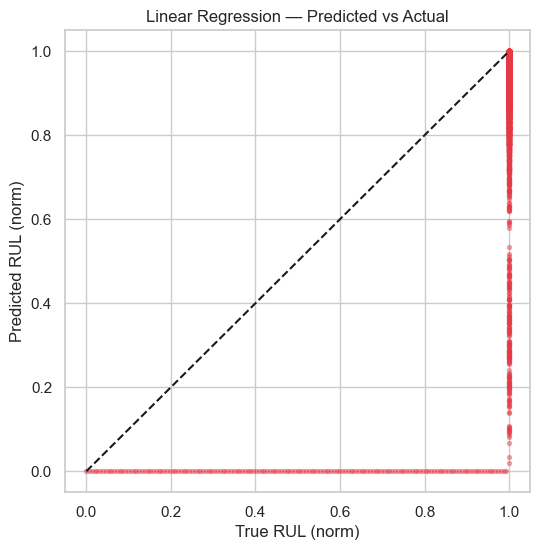

In [9]:
# Visualize — RUL fit + predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(res_lr['y_true'], res_lr['y_pred'], s=8, alpha=0.4, color='#e63946')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('True RUL (norm)'); plt.ylabel('Predicted RUL (norm)')
plt.title('Linear Regression — Predicted vs Actual')

<Axes: title={'center': 'Linear Regression — RUL, first 300 samples'}>

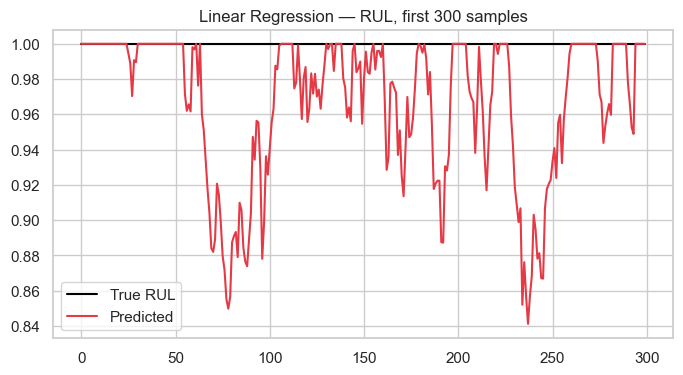

In [10]:
n = 300
pd.DataFrame({
    'True RUL': res_lr['y_true'][:n],
    'Predicted': res_lr['y_pred'][:n]
}).plot(figsize=(8,4), color=['black', '#e63946'],
        title=f'Linear Regression — RUL, first {n} samples')

#### 3.2 XGBoost
Strongest tabular baseline (gradient-boosted trees). Note: trees cannot extrapolate
beyond the training RUL range — a known limitation to keep in mind on test3.

In [11]:
# Model Initialization + Training
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    objective='reg:squarederror', random_state=SEED, n_jobs=-1)

t0 = time.time()
xgb_model.fit(Xf_train, yf_train, sample_weight=sw_flat,
              eval_set=[(Xf_val, yf_val)] if len(Xf_val) else None, verbose=False)
xgb_train_time = time.time() - t0
print(f'XGBoost trained in {xgb_train_time:.3f}s  (weighted={sw_flat is not None})')

XGBoost trained in 0.276s  (weighted=True)


In [12]:
# Predict + Evaluate
t0 = time.time()
xgb_pred = xgb_model.predict(Xf_test)
xgb_pred_time = time.time() - t0

res_xgb = eval_rul('XGBoost', yf_test, xgb_pred,
                   xgb_train_time, xgb_pred_time, model=xgb_model)

XGBoost
  RMSE (norm) : 0.0416   |  MAE (norm) : 0.0120
  RMSE (min)  : 63.3    |  MAE (min)  : 18.2
  Asym score  : 14315.3
  Train time  : 0.276s  |  Pred time : 0.0156s


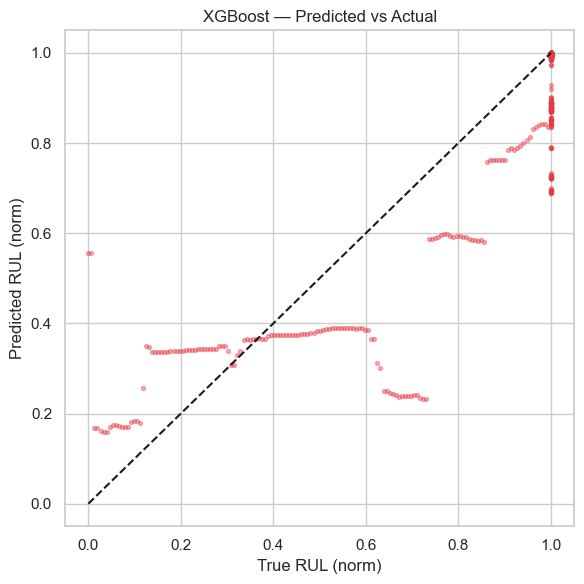

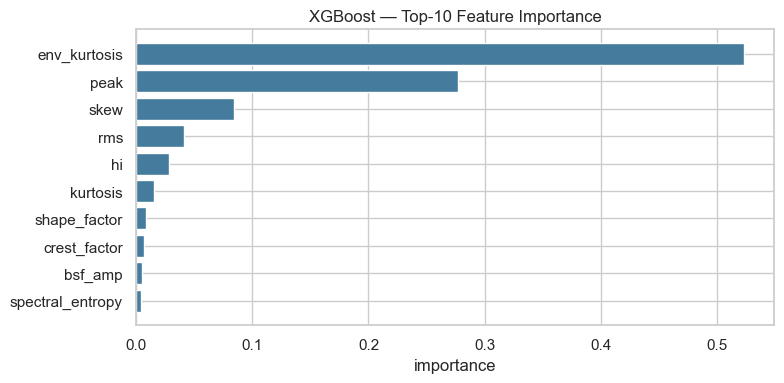

In [13]:
# Visualize — RUL fit + feature importance (cross-check with EDA Spearman top-10)
plt.figure(figsize=(6,6))
plt.scatter(res_xgb['y_true'], res_xgb['y_pred'], s=8, alpha=0.4, color='#e63946')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('True RUL (norm)'); plt.ylabel('Predicted RUL (norm)')
plt.title('XGBoost — Predicted vs Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fit_xgboost.png'), dpi=150, bbox_inches='tight')
plt.show()

imp   = xgb_model.feature_importances_
order = np.argsort(imp)[-10:][::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([FEATURE_COLS[i] for i in order][::-1], imp[order][::-1], color='#457b9d')
ax.set_title('XGBoost — Top-10 Feature Importance'); ax.set_xlabel('importance')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'xgb_importance.png'), dpi=150, bbox_inches='tight'); plt.show()

<Axes: title={'center': 'XGBoost — RUL, first 300 samples'}>

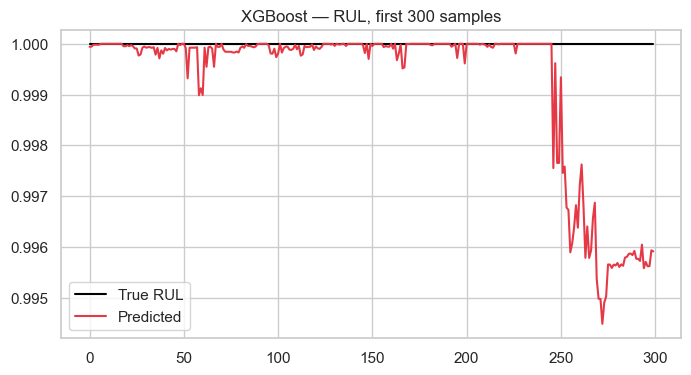

In [14]:
n = 300
pd.DataFrame({
    'True RUL': res_xgb['y_true'][:n],
    'Predicted': res_xgb['y_pred'][:n]
}).plot(figsize=(8,4), color=['black', '#e63946'],
        title=f'XGBoost — RUL, first {n} samples')

#### 3.3 Multi-Layer Perceptron (MLP)
A deep model on **flat** features (no time order). Its role is an ablation against LSTM:
MLP (deep, no temporal) vs LSTM (deep, temporal) isolates whether sequence modelling helps.
With only one training trajectory it can overfit → early stopping + L2 (`alpha`) are used.

In [15]:
# Model Initialization + Training
# MLPRegressor.fit has no sample_weight, so resample the training set (with
# replacement) according to the LDS weights instead, to approximate weighted training
#
# also apply a second, MLP-only scaler on top of NB2's baseline-relative one:
# NB2 scales against the healthy baseline only, so near-failure samples sit far
# from 0 by design — fine for XGBoost/LR, but MLP needs roughly uniform feature
# scale or its gradient descent collapses to a constant prediction
rng = np.random.default_rng(SEED)
idx = rng.choice(len(Xf_train), size=len(Xf_train), replace=True, p=sw_flat / sw_flat.sum())

mlp_scaler   = StandardScaler().fit(Xf_train[idx])
Xf_train_mlp = mlp_scaler.transform(Xf_train[idx])
Xf_test_mlp  = mlp_scaler.transform(Xf_test)

mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=1e-3,                 # L2 regularisation (overfit guard)
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED)

t0 = time.time()
mlp_model.fit(Xf_train_mlp, yf_train[idx])
mlp_train_time = time.time() - t0
print(f'MLP trained in {mlp_train_time:.3f}s  ({mlp_model.n_iter_} iters, scaled+resampled)')

MLP trained in 1.399s  (242 iters, scaled+resampled)


In [16]:
# Predict + Evaluate
t0 = time.time()
mlp_pred = mlp_model.predict(Xf_test_mlp)
mlp_pred_time = time.time() - t0

res_mlp = eval_rul('MLP', yf_test, mlp_pred,
                   mlp_train_time, mlp_pred_time, model=mlp_model)

MLP
  RMSE (norm) : 0.0917   |  MAE (norm) : 0.0135
  RMSE (min)  : 139.3    |  MAE (min)  : 20.5
  Asym score  : 41942601.4
  Train time  : 1.399s  |  Pred time : 0.0095s


Text(0.5, 1.0, 'MLP — Predicted vs Actual')

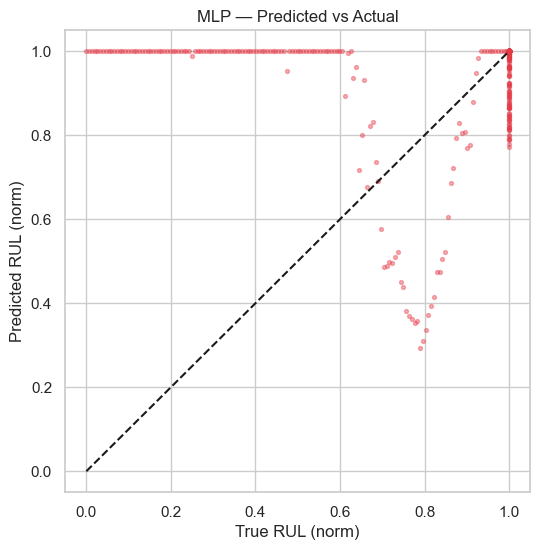

In [17]:
# Visualize — RUL fit + predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(res_mlp['y_true'], res_mlp['y_pred'], s=8, alpha=0.4, color='#e63946')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('True RUL (norm)'); plt.ylabel('Predicted RUL (norm)')
plt.title('MLP — Predicted vs Actual')

<Axes: title={'center': 'MLP — RUL, first 300 samples'}>

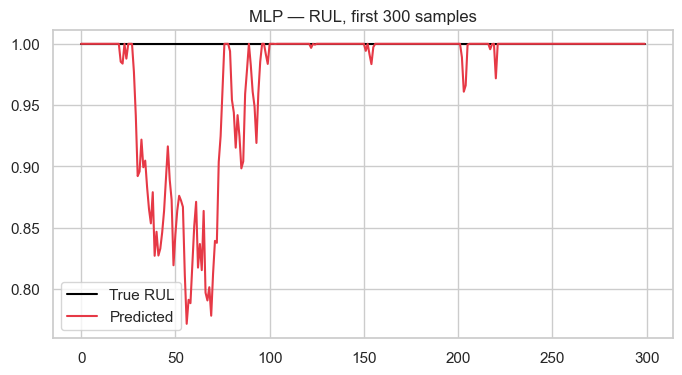

In [18]:
n = 300
pd.DataFrame({
    'True RUL': res_mlp['y_true'][:n],
    'Predicted': res_mlp['y_pred'][:n]
}).plot(figsize=(8,4), color=['black', '#e63946'],
        title=f'MLP — RUL, first {n} samples')

#### 3.4 Long Short-Term Memory (LSTM)
The only baseline that uses the **temporal** structure (sliding windows). This same
backbone becomes the Bayesian tier (MC Dropout / Deep Ensemble) in NB4, so dropout=0.2
is kept deliberately. Uses LDS sample weights via a weighted MSE (train only).

In [19]:
import torch
print(torch.__version__)

2.2.2+cpu


In [20]:
import ctypes
ctypes.CDLL("msvcp140.dll")
ctypes.CDLL("vcruntime140.dll")
ctypes.CDLL("vcruntime140_1.dll")
ctypes.CDLL("vcomp140.dll")
print("Tất cả runtime VC++ nạp OK")

Tất cả runtime VC++ nạp OK


In [21]:
# Model Initialization — define architecture + tensors
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

tt = lambda a: torch.tensor(np.asarray(a), dtype=torch.float32)
Xtr, ytr = tt(Xs_train), tt(ys_train).unsqueeze(-1)
Xvl, yvl = tt(Xs_val),   tt(ys_val).unsqueeze(-1)
Xte      = tt(Xs_test)
wtr = tt(sw_seq).unsqueeze(-1) if sw_seq is not None else torch.ones_like(ytr)

train_dl = DataLoader(TensorDataset(Xtr, ytr, wtr), batch_size=64, shuffle=True)

class LSTMRegressor(nn.Module):
    def __init__(self, n_feat, hidden=64, layers=2, p=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=layers,
                            batch_first=True, dropout=p if layers > 1 else 0.0)
        self.head = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(),
                                  nn.Dropout(p), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])     # last timestep

lstm_model = LSTMRegressor(Xtr.shape[-1]).to(device)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-5)
print(lstm_model)

Device: cpu


[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2+cpu
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


LSTMRegressor(
  (lstm): LSTM(15, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [22]:
# Model Training — weighted MSE, early stopping on validation RMSE
def weighted_mse(pred, target, w):
    return torch.mean(w * (pred - target) ** 2)

best_val, best_state, patience, bad = np.inf, None, 15, 0
t0 = time.time()
for epoch in range(150):
    lstm_model.train()
    for xb, yb, wb in train_dl:
        xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
        optimizer.zero_grad()
        weighted_mse(lstm_model(xb), yb, wb).backward()
        optimizer.step()

    lstm_model.eval()
    with torch.no_grad():
        vp = lstm_model(Xvl.to(device)).cpu().numpy().ravel() if len(Xvl) else None
    vr = rmse(ys_val, vp) if (vp is not None and len(ys_val)) else float('nan')
    if vp is not None and vr < best_val:
        best_val, bad = vr, 0
        best_state = {k: v.cpu().clone() for k, v in lstm_model.state_dict().items()}
    else:
        bad += 1
    if (epoch + 1) % 10 == 0:
        print(f'  epoch {epoch+1:3d} | val RMSE_norm={vr:.4f} | best={best_val:.4f}')
    if bad >= patience:
        print(f'  early stop @ epoch {epoch+1}'); break

if best_state is not None:
    lstm_model.load_state_dict(best_state)
lstm_train_time = time.time() - t0
print(f'LSTM trained in {lstm_train_time:.1f}s  (best val RMSE_norm={best_val:.4f})')

  epoch  10 | val RMSE_norm=0.1131 | best=0.1131
  epoch  20 | val RMSE_norm=0.1408 | best=0.1131
  epoch  30 | val RMSE_norm=0.1395 | best=0.1120
  epoch  40 | val RMSE_norm=0.1558 | best=0.1120
  early stop @ epoch 40
LSTM trained in 9.4s  (best val RMSE_norm=0.1120)


In [23]:
# Predict + Evaluate
lstm_model.eval()
t0 = time.time()
with torch.no_grad():
    lstm_pred = lstm_model(Xte.to(device)).cpu().numpy().ravel()
lstm_pred_time = time.time() - t0

res_lstm = eval_rul('LSTM', ys_test, lstm_pred,
                    lstm_train_time, lstm_pred_time, model=lstm_model,
                    note=f'val_RMSE={best_val:.4f}')

# Save the backbone for the Bayesian tier (NB4)
torch.save(lstm_model.state_dict(), os.path.join(OUT_DIR, 'lstm_baseline.pt'))

LSTM
  RMSE (norm) : 0.0689   |  MAE (norm) : 0.0173
  RMSE (min)  : 104.8    |  MAE (min)  : 26.3
  Asym score  : 1903346.9
  Train time  : 9.407s  |  Pred time : 0.1680s


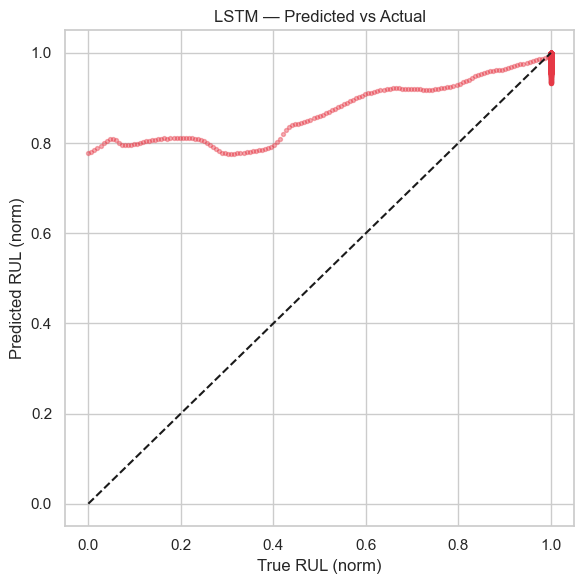

In [24]:
# Visualize — RUL fit + predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(res_lstm['y_true'], res_lstm['y_pred'], s=8, alpha=0.4, color='#e63946')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('True RUL (norm)'); plt.ylabel('Predicted RUL (norm)')
plt.title('LSTM — Predicted vs Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fit_lstm.png'), dpi=150, bbox_inches='tight')
plt.show()

<Axes: title={'center': 'LSTM — RUL, first 600 samples'}>

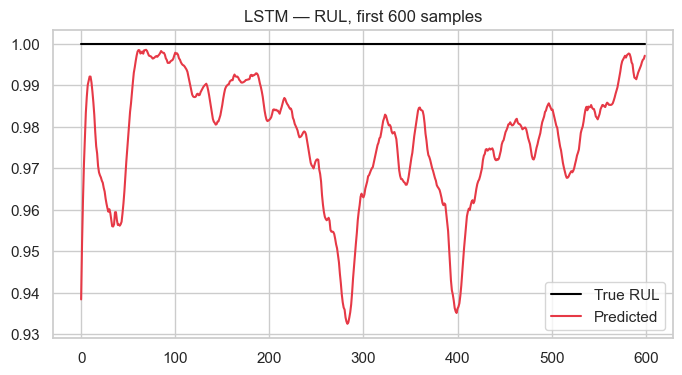

In [25]:
n = 600
pd.DataFrame({
    'True RUL': res_lstm['y_true'][:n],
    'Predicted': res_lstm['y_pred'][:n]
}).plot(figsize=(8,4), color=['black', '#e63946'],
        title=f'LSTM — RUL, first {n} samples')

#### 4. Summarisation

In [26]:
# Build comparison table from all collected results
summary_df = pd.DataFrame([
    {
        'Model'        : r['model_name'],
        'RMSE_norm'    : round(r['rmse_norm'], 4),
        'MAE_norm'     : round(r['mae_norm'],  4),
        'RMSE_min'     : round(r['rmse_min'],  1),
        'MAE_min'      : round(r['mae_min'],   1),
        'Asym_score'   : round(r['score'],     1),
        'Train_time_s' : round(r['train_time'], 3),
        'Pred_time_s'  : round(r['pred_time'],  4),
    }
    for r in RESULTS
])
print('Baseline Model Comparison (test3):')
print(summary_df.to_string(index=False))

Baseline Model Comparison (test3):
                 Model  RMSE_norm  MAE_norm  RMSE_min  MAE_min  Asym_score  Train_time_s  Pred_time_s
Mean predictor (floor)     0.1756    0.1682     266.9    255.7   3537111.5         0.000       0.0000
     Linear Regression     0.1727    0.0864     262.5    131.3   2898165.9         0.010       0.0010
               XGBoost     0.0416    0.0120      63.3     18.2     14315.3         0.276       0.0156
                   MLP     0.0917    0.0135     139.3     20.5  41942601.4         1.399       0.0095
                  LSTM     0.0689    0.0173     104.8     26.3   1903346.9         9.407       0.1680


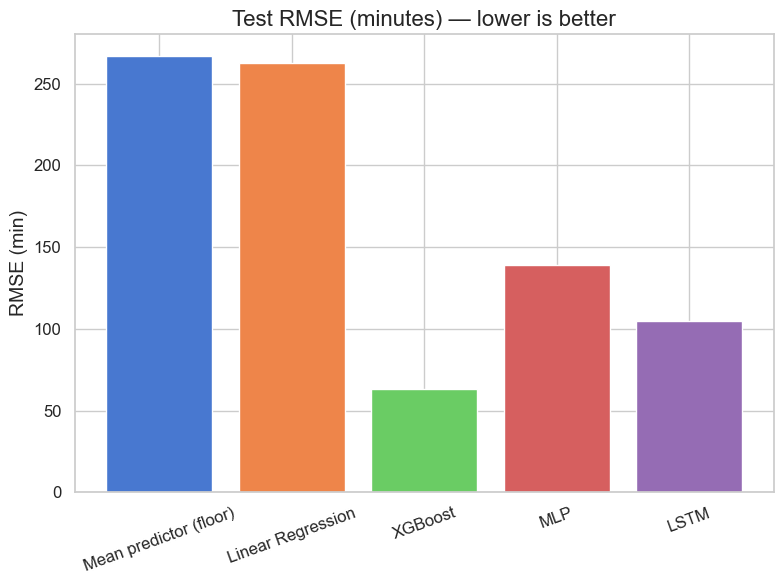

In [27]:
# Baseline comparison — Test RMSE bar chart & Predicted-vs-Actual scatter
# Figure 1: Test RMSE comparison (bar chart)
names = summary_df['Model'].tolist()

fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(names, summary_df['RMSE_min'], color=sns.color_palette('muted', len(names)))
ax1.set_title('Test RMSE (minutes) — lower is better', fontsize=16)
ax1.set_ylabel('RMSE (min)', fontsize=14)
ax1.tick_params(axis='x', rotation=20, labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'baseline_rmse_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

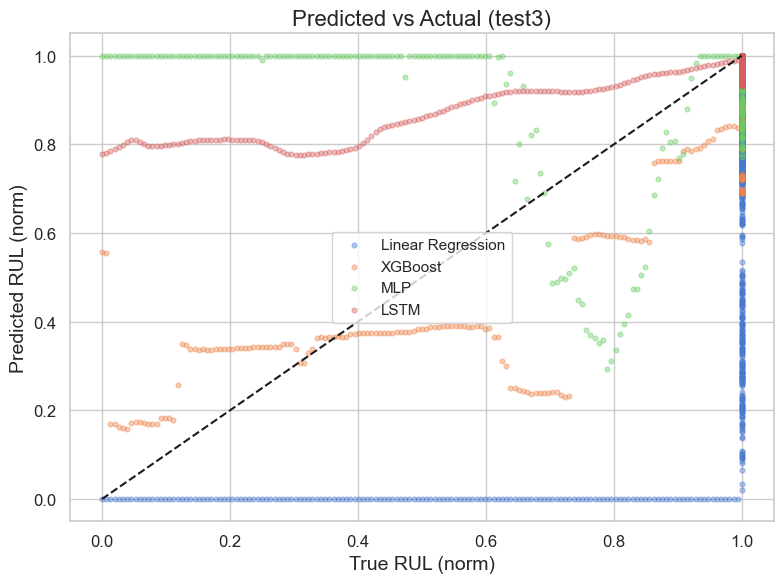

In [28]:
# Figure 2: Predicted vs Actual scatter plot
fig2, ax2 = plt.subplots(figsize=(8, 6))
for r in RESULTS:
    if 'floor' in r['model_name']:      # skip the flat mean line in the scatter
        continue
    ax2.scatter(r['y_true'], r['y_pred'], s=12, alpha=0.4, label=r['model_name'])
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax2.set_xlabel('True RUL (norm)', fontsize=14)
ax2.set_ylabel('Predicted RUL (norm)', fontsize=14)
ax2.set_title('Predicted vs Actual (test3)', fontsize=16)
ax2.tick_params(axis='both', labelsize=12)
ax2.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'baseline_predicted_vs_actual.png'), dpi=200, bbox_inches='tight')
plt.show()


In [29]:
# Save baseline results for the Bayesian tier (NB4) to overlay on
summary_df.to_csv(os.path.join(OUT_DIR, 'baseline_results.csv'), index=False)
np.savez_compressed(
    os.path.join(OUT_DIR, 'baseline_predictions.npz'),
    **{f"{r['model_name'].split()[0]}__true": r['y_true'] for r in RESULTS},
    **{f"{r['model_name'].split()[0]}__pred": r['y_pred'] for r in RESULTS})

print('Saved to', os.path.abspath(OUT_DIR))
print('  baseline_results.csv      → metric table')
print('  baseline_predictions.npz  → per-model (true, pred)')
print('  lstm_baseline.pt          → LSTM backbone for NB4')

Saved to C:\Users\Windown\OneDrive - Aston University\1_Dissertation\1_Project_Dissertation\baseline_output
  baseline_results.csv      → metric table
  baseline_predictions.npz  → per-model (true, pred)
  lstm_baseline.pt          → LSTM backbone for NB4


**Reading the table.** Every model should beat the **mean-predictor floor** — if one
doesn't, suspect the pipeline, not the model. Complexity rises Linear → XGBoost → MLP →
LSTM; the MLP-vs-LSTM gap shows whether temporal modelling pays off. These are
point predictions (accuracy only); the Bayesian tier adds calibrated uncertainty.